In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models, optimizers

In [2]:
img_size = (224, 224)
batch_size = 32
train_dir = r"c:\Users\Admin\OneDrive\Documents\File_save_bai_tap_random\dataset\seg"
test_dir = r"c:\Users\Admin\OneDrive\Documents\File_save_bai_tap_random\dataset\seg_test"

In [3]:
# 1. Data generators
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

num_classes = train_gen.num_classes

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [4]:
# 2. Transfer learning model
base_model = MobileNetV2(weights="imagenet", include_top=False,
                         input_shape=img_size + (3,))
base_model.trainable = False  # bước 1: chỉ train head

inputs = layers.Input(shape=img_size + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [5]:
# 3. Train
history = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen
)

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 170s 474ms/step - accuracy: 0.5310 - loss: 1.2153 - val_accuracy: 0.7967 - val_loss: 0.6339
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 163s 465ms/step - accuracy: 0.7813 - loss: 0.6091 - val_accuracy: 0.8442 - val_loss: 0.4556
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 162s 462ms/step - accuracy: 0.8311 - loss: 0.4740 - val_accuracy: 0.8730 - val_loss: 0.3825
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 153s 434ms/step - accuracy: 0.8516 - loss: 0.4199 - val_accuracy: 0.8798 - val_loss: 0.3459
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 162s 462ms/step - accuracy: 0.8573 - loss: 0.3856 - val_accuracy: 0.8795 - val_loss: 0.3354
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 159s 452ms/step - accuracy: 0.8687 - loss: 0.3679 - val_accuracy: 0.8852 - val_loss: 0.3092
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 185s 527ms/step - accuracy: 0.8691 - loss: 0.3535 - val_accuracy: 0.8877 - val_loss: 0.3016
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 224s 639ms/step - accuracy: 0.8775 -

In [6]:
# 4. Evaluate on test
test_loss, test_acc = model.evaluate(test_gen)
print("Test accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 39s 414ms/step - accuracy: 0.9103 - loss: 0.2502
Test accuracy: 0.9103333353996277


In [8]:
import pandas as pd

# Lưu lịch sử huấn luyện để vẽ biểu đồ sau này
hist_df = pd.DataFrame(history.history)
hist_df.to_csv("history.csv", index=False)
print("Saved training history to history.csv")

Saved training history to history.csv


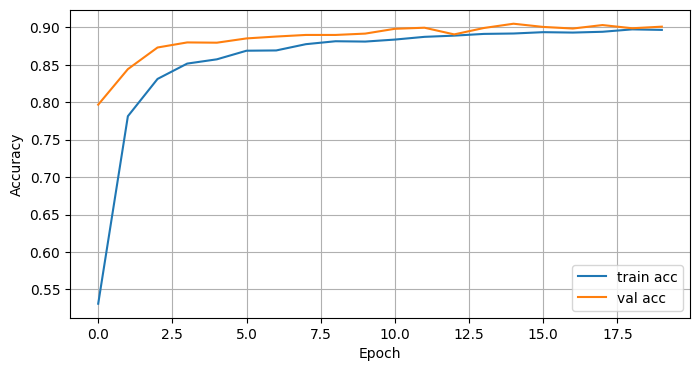

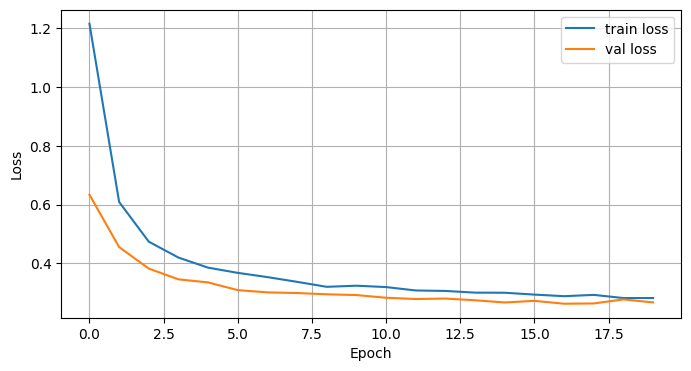

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

hist_df = pd.read_csv("history.csv")

plt.figure(figsize=(8,4))
plt.plot(hist_df["accuracy"], label="train acc")
plt.plot(hist_df["val_accuracy"], label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(hist_df["loss"], label="train loss")
plt.plot(hist_df["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# Lưu mô hình đã huấn luyện để dùng lại sau này
model.save("scene_mobilenetv2.h5")
print("Saved model to scene_mobilenetv2.h5")

Saved model to scene_mobilenetv2.h5


In [ ]:
import os
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

# Thư mục chứa ảnh cần phân loại
sample_dir = r"C:\Users\Admin\OneDrive\Documents\File_save_bai_tap_random\dataset\sample"

# Load mô hình đã huấn luyện
model = load_model("scene_mobilenetv2.h5")

# Lấy tên các lớp từ train_gen
class_indices = train_gen.class_indices
labels = dict((v, k) for k, v in class_indices.items())

# Lặp qua tất cả ảnh trong thư mục và phân loại
for img_name in os.listdir(sample_dir):
    img_path = os.path.join(sample_dir, img_name)
    if not img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
        continue
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    pred = model.predict(img_array)
    predicted_class = np.argmax(pred, axis=1)[0]
    print(f"{img_name}: {labels[predicted_class]}")